In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

#**READ CSV**

In [ ]:
df = pd.read_csv("SaYoPillow.csv")



In [ ]:
print(df.shape)
# print(df.describe())
print(df.info())

(630, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sr      630 non-null    float64
 1   rr      630 non-null    float64
 2   t       630 non-null    float64
 3   lm      630 non-null    float64
 4   bo      630 non-null    float64
 5   rem     630 non-null    float64
 6   sr.1    630 non-null    float64
 7   hr      630 non-null    float64
 8   sl      630 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 44.4 KB
None


In [ ]:
print(df["sl"].value_counts())
print(df["hr"].value_counts())
print(df["sr.1"].value_counts())
print(df["rem"].value_counts())
print(df["bo"].value_counts())
print(df["lm"].value_counts())
print(df["t"].value_counts())
print(df["rr"].value_counts())
print(df["sr"].value_counts())

3    126
1    126
0    126
2    126
4    126
Name: sl, dtype: int64
65.00    2
60.00    2
75.00    2
55.00    2
53.52    1
        ..
73.72    1
69.96    1
52.40    1
64.44    1
63.48    1
Name: hr, Length: 626, dtype: int64
0.000    127
2.000      2
5.000      2
7.000      2
0.752      1
        ... 
6.312      1
5.416      1
6.664      1
3.152      1
4.088      1
Name: sr.1, Length: 501, dtype: int64
95.00     2
85.00     2
100.00    2
80.00     2
74.08     1
         ..
99.36     1
97.48     1
69.60     1
93.88     1
91.96     1
Name: rem, Length: 626, dtype: int64
95.000    2
88.000    2
92.000    2
90.000    2
89.840    1
         ..
96.488    1
89.744    1
88.992    1
95.960    1
91.392    1
Name: bo, Length: 626, dtype: int64
12.000    2
10.000    2
17.000    2
8.000     2
6.816     1
         ..
16.360    1
14.480    1
5.920     1
11.776    1
11.392    1
Name: lm, Length: 626, dtype: int64
96.000    2
90.000    2
94.000    2
92.000    2
91.840    1
         ..
98.232    1
91.74

In [ ]:
print(df.corr())

            sr        rr         t        lm        bo       rem      sr.1  \
sr    1.000000  0.976268 -0.902475  0.981078 -0.903140  0.950600 -0.920554   
rr    0.976268  1.000000 -0.889237  0.991738 -0.889210  0.935572 -0.891855   
t    -0.902475 -0.889237  1.000000 -0.896412  0.998108 -0.857299  0.954860   
lm    0.981078  0.991738 -0.896412  1.000000 -0.898527  0.964703 -0.901102   
bo   -0.903140 -0.889210  0.998108 -0.898527  1.000000 -0.862136  0.950189   
rem   0.950600  0.935572 -0.857299  0.964703 -0.862136  1.000000 -0.893952   
sr.1 -0.920554 -0.891855  0.954860 -0.901102  0.950189 -0.893952  1.000000   
hr    0.976268  1.000000 -0.889237  0.991738 -0.889210  0.935572 -0.891855   
sl    0.975322  0.963516 -0.962354  0.971071 -0.961092  0.951988 -0.973036   

            hr        sl  
sr    0.976268  0.975322  
rr    1.000000  0.963516  
t    -0.889237 -0.962354  
lm    0.991738  0.971071  
bo   -0.889210 -0.961092  
rem   0.935572  0.951988  
sr.1 -0.891855 -0.973036  
hr 

#**RENAMING COLUMNS**

In [ ]:
df.rename(columns={"sr": "snoring rate", "rr": "respiration rate", "t":"body temperature", "lm":"limb movement", "bo":"blood oxygen", "rem":"eye movement", "sr.1":"sleeping hours", "hr":"heart rate", "sl":"stress level"},inplace=True)

In [ ]:
print(df.head())
print(df.tail())

   snoring rate  respiration rate  body temperature  limb movement  \
0         93.80            25.680            91.840         16.600   
1         91.64            25.104            91.552         15.880   
2         60.00            20.000            96.000         10.000   
3         85.76            23.536            90.768         13.920   
4         48.12            17.248            97.872          6.496   

   blood oxygen  eye movement  sleeping hours  heart rate  stress level  
0        89.840         99.60           1.840       74.20             3  
1        89.552         98.88           1.552       72.76             3  
2        95.000         85.00           7.000       60.00             1  
3        88.768         96.92           0.768       68.84             3  
4        96.248         72.48           8.248       53.12             0  
     snoring rate  respiration rate  body temperature  limb movement  \
625        69.600            20.960            92.960         1

# **Feature Description**

**Snoring Rate**:Snoring is a sound generated during sleep by vibration of loose tissue in the upper airway.

**Respiratory rate**: The number of breaths per minute or, more formally, the number of movements indicative of inspiration and expiration per unit time.

**Body temperature**: Body temperature is the degree of hotness or coldness of a body.

**Limb movement**: Limb movement refers to the movement of one or more of the limbs, including the arms and legs.

**Blood Oxygen**: Blood oxygen is the amount of oxygen that is carried by red blood cells in the body.

**Eye movement**: Eye movement refers to the motion and coordination of the eyes as they track and fixate on visual targets.

**Sleeping hours**: Sleeping hours refers to the amount of time an individual spends asleep during a given period of time.

**Heart rate**: Heart rate refers to the number of times the heart beats per minute (bpm).

**Stress level**: Stress level refers to the degree of perceived psychological or emotional pressure or tension that an individual is experiencing in response to various internal or external factors

#**DATA PREPROCESSING**

In [ ]:
print(df.isnull().sum())
print(df.shape)
print(df.duplicated().sum())
df = df.drop_duplicates()
df.head()
df = df.dropna()

snoring rate        0
respiration rate    0
body temperature    0
limb movement       0
blood oxygen        0
eye movement        0
sleeping hours      0
heart rate          0
stress level        0
dtype: int64
(630, 9)
0


#**INDEPENDENT AND DEPENDENT VARIABLES**

In [ ]:

x = df.iloc[:, :-1]
y = df.iloc[:, -1]


#**Train Test Split**


In [ ]:
print(type(x))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3)


<class 'pandas.core.frame.DataFrame'>


# **VISUALIZATION**

<Axes: ylabel='count'>

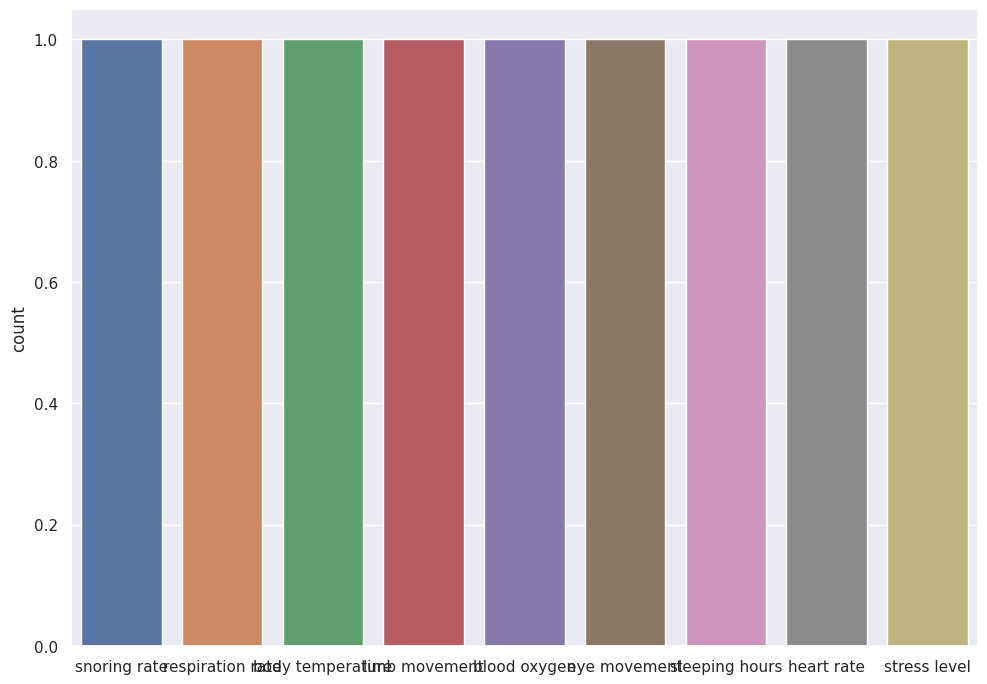

In [ ]:
sns.set (rc= {'figure.figsize': (11.7,8.27)})
sns.countplot(x = df.columns)

**Sleeping hours Vs Stress level**

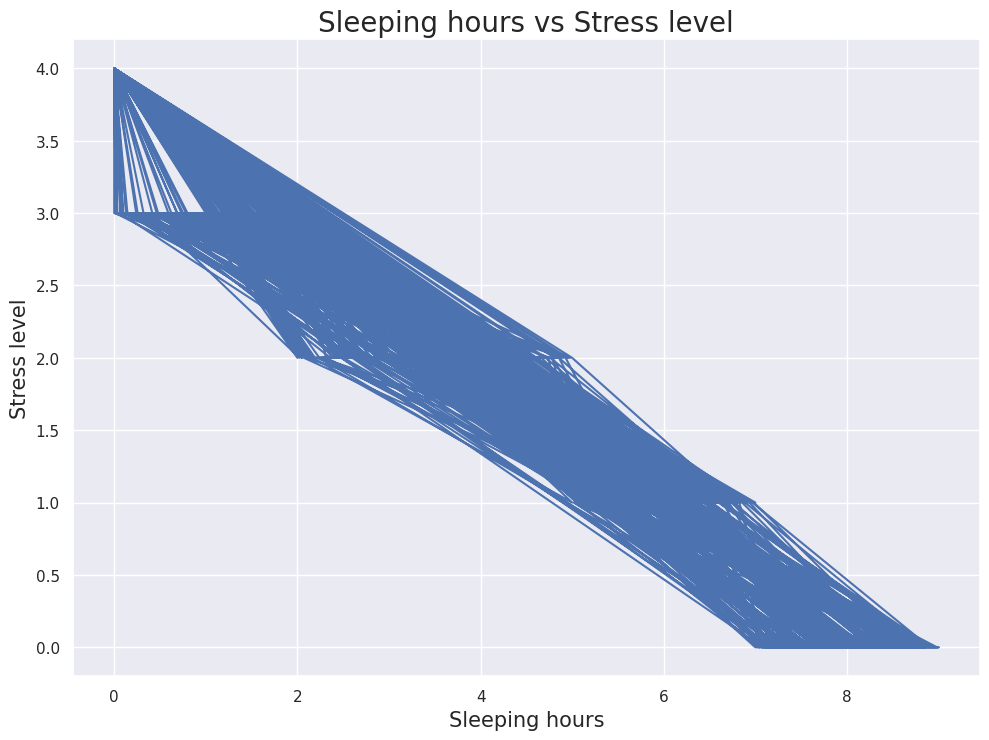

In [ ]:
plt.title("Sleeping hours vs Stress level", fontsize = 20)
plt.xlabel("Sleeping hours", fontsize = 15)
plt.ylabel("Stress level", fontsize = 15)
plt.plot(df['sleeping hours'], df['stress level'], linestyle = "solid")

##**Snoring rate Vs Stress level**

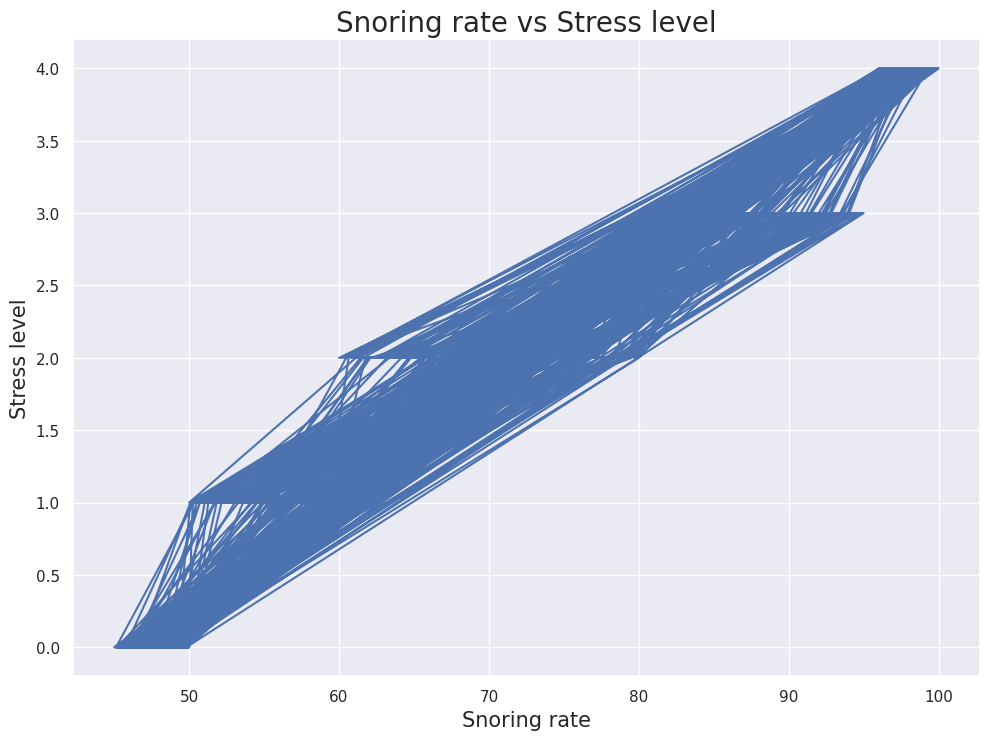

In [ ]:
plt.title("Snoring rate vs Stress level", fontsize = 20)
plt.xlabel("Snoring rate", fontsize = 15)
plt.ylabel("Stress level", fontsize = 15)
plt.plot(df['snoring rate'], df['stress level'], linestyle = "solid")

#**Heart rate Vs Stress level**

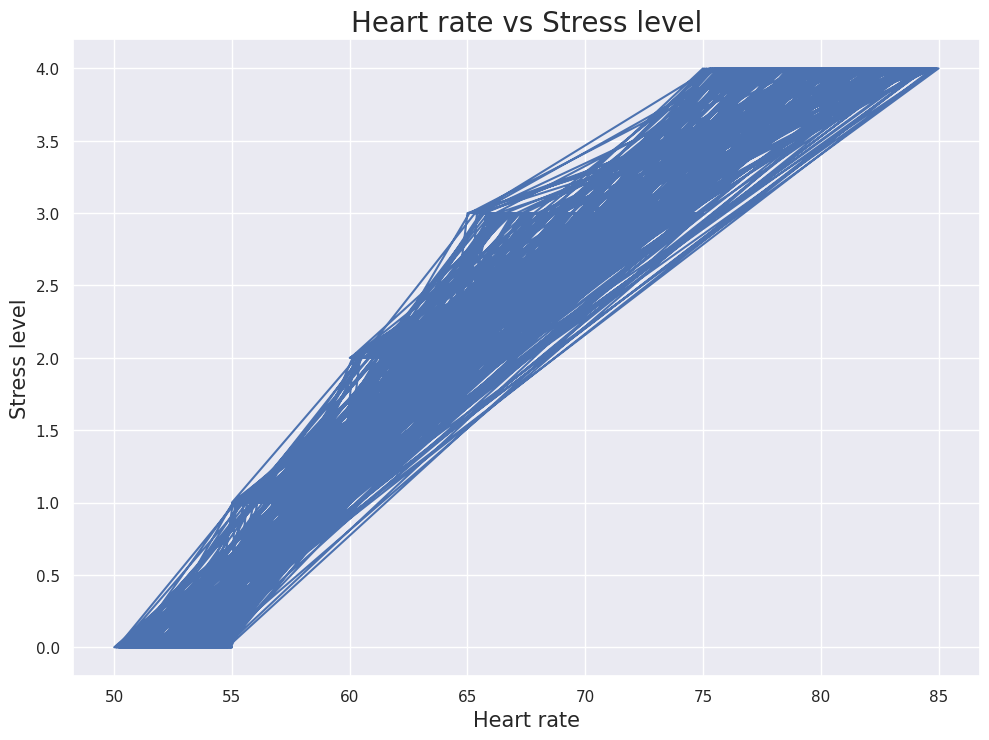

In [ ]:
plt.title("Heart rate vs Stress level", fontsize = 20)
plt.xlabel("Heart rate", fontsize = 15)
plt.ylabel("Stress level", fontsize = 15)
plt.plot(df['heart rate'], df['stress level'], linestyle = "solid")

#**Body Oxygen Vs Stress level**

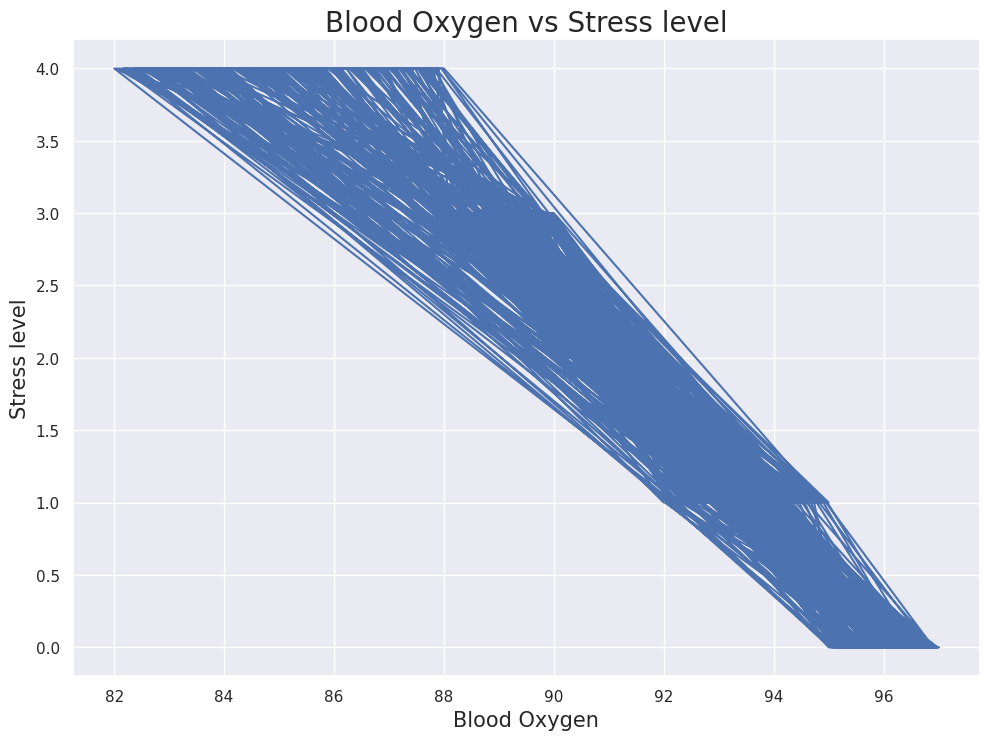

In [ ]:
plt.title("Blood Oxygen vs Stress level", fontsize = 20)
plt.xlabel("Blood Oxygen", fontsize = 15)
plt.ylabel("Stress level", fontsize = 15)
plt.plot(df['blood oxygen'], df['stress level'], linestyle = "solid")

#**Respiration rate Vs Stress level**

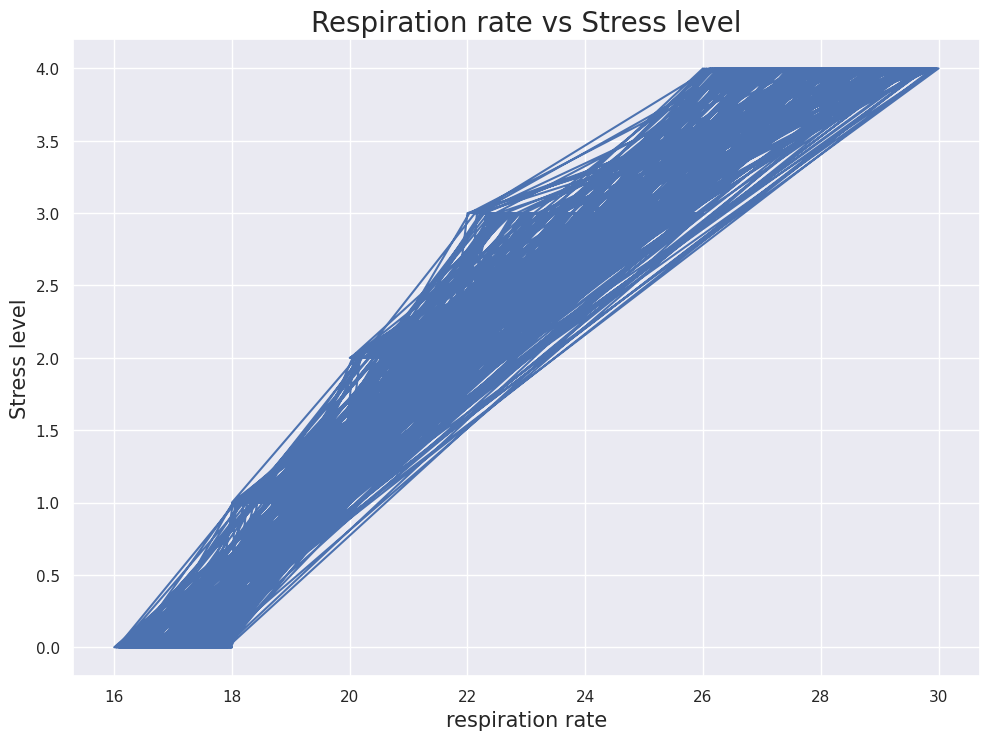

In [ ]:
plt.title("Respiration rate vs Stress level", fontsize = 20)
plt.xlabel("respiration rate", fontsize = 15)
plt.ylabel("Stress level", fontsize = 15)
plt.plot(df['respiration rate'], df['stress level'], linestyle = "solid")

#  **Body temperature Vs Stress level**

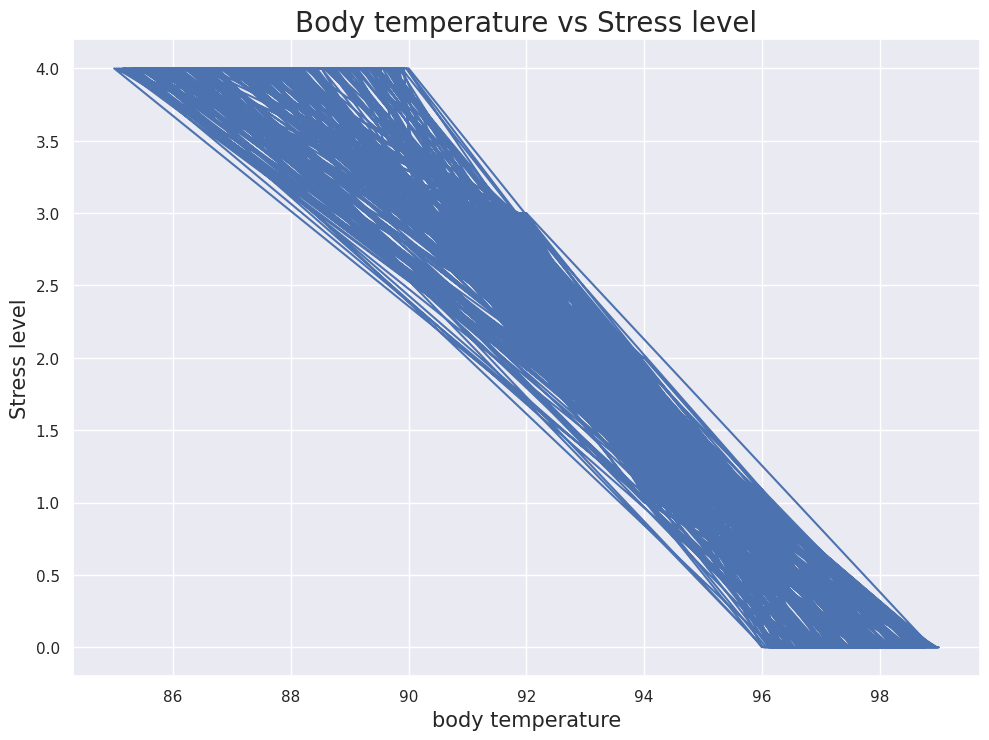

In [ ]:
plt.title("Body temperature vs Stress level", fontsize = 20)
plt.xlabel("body temperature", fontsize = 15)
plt.ylabel("Stress level", fontsize = 15)
plt.plot(df['body temperature'], df['stress level'], linestyle = "solid")

#**Limb movement Vs Stress level**

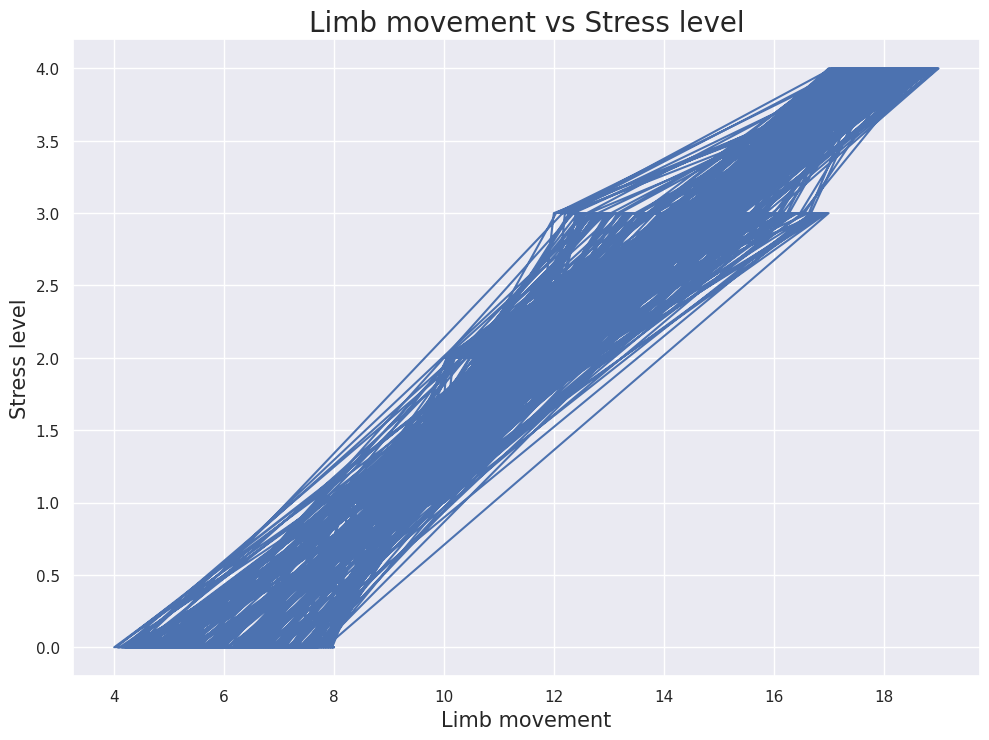

In [ ]:
plt.title("Limb movement vs Stress level", fontsize = 20)
plt.xlabel("Limb movement", fontsize = 15)
plt.ylabel("Stress level", fontsize = 15)
plt.plot(df['limb movement'], df['stress level'], linestyle = "solid")

#**Eye movement Vs Stress level**

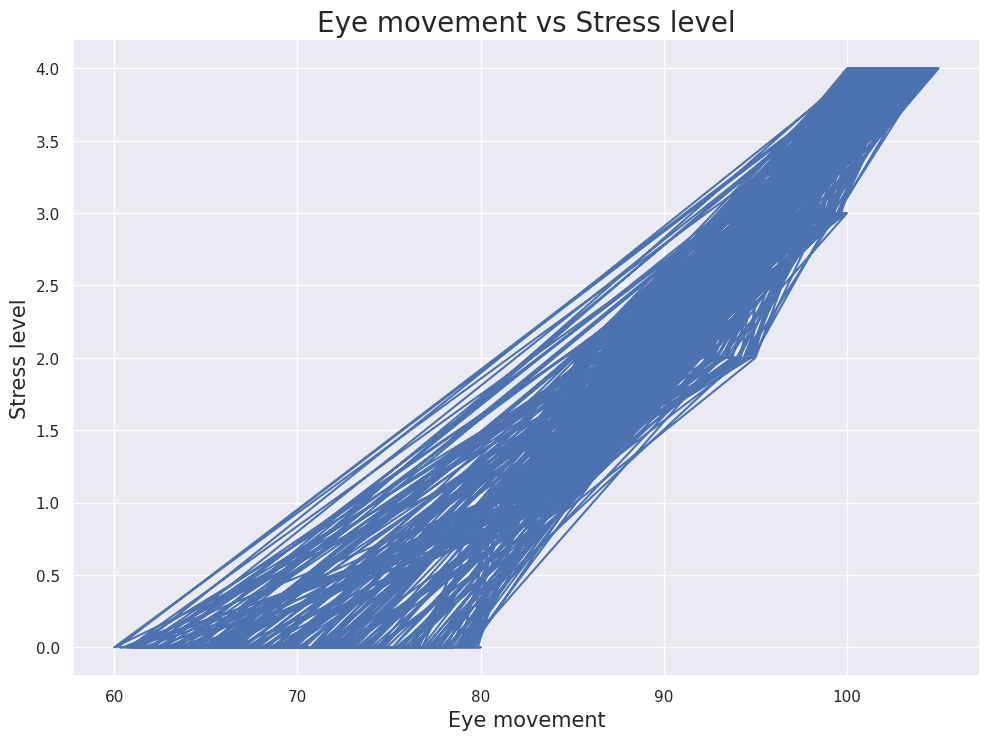

In [ ]:
plt.title("Eye movement vs Stress level", fontsize = 20)
plt.xlabel("Eye movement", fontsize = 15)
plt.ylabel("Stress level", fontsize = 15)
plt.plot(df['eye movement'], df['stress level'], linestyle = "solid")

array([[<Axes: xlabel='snoring rate', ylabel='snoring rate'>,
        <Axes: xlabel='respiration rate', ylabel='snoring rate'>,
        <Axes: xlabel='body temperature', ylabel='snoring rate'>,
        <Axes: xlabel='limb movement', ylabel='snoring rate'>,
        <Axes: xlabel='blood oxygen', ylabel='snoring rate'>,
        <Axes: xlabel='eye movement', ylabel='snoring rate'>,
        <Axes: xlabel='sleeping hours', ylabel='snoring rate'>,
        <Axes: xlabel='heart rate', ylabel='snoring rate'>,
        <Axes: xlabel='stress level', ylabel='snoring rate'>],
       [<Axes: xlabel='snoring rate', ylabel='respiration rate'>,
        <Axes: xlabel='respiration rate', ylabel='respiration rate'>,
        <Axes: xlabel='body temperature', ylabel='respiration rate'>,
        <Axes: xlabel='limb movement', ylabel='respiration rate'>,
        <Axes: xlabel='blood oxygen', ylabel='respiration rate'>,
        <Axes: xlabel='eye movement', ylabel='respiration rate'>,
        <Axes: xlabel='slee

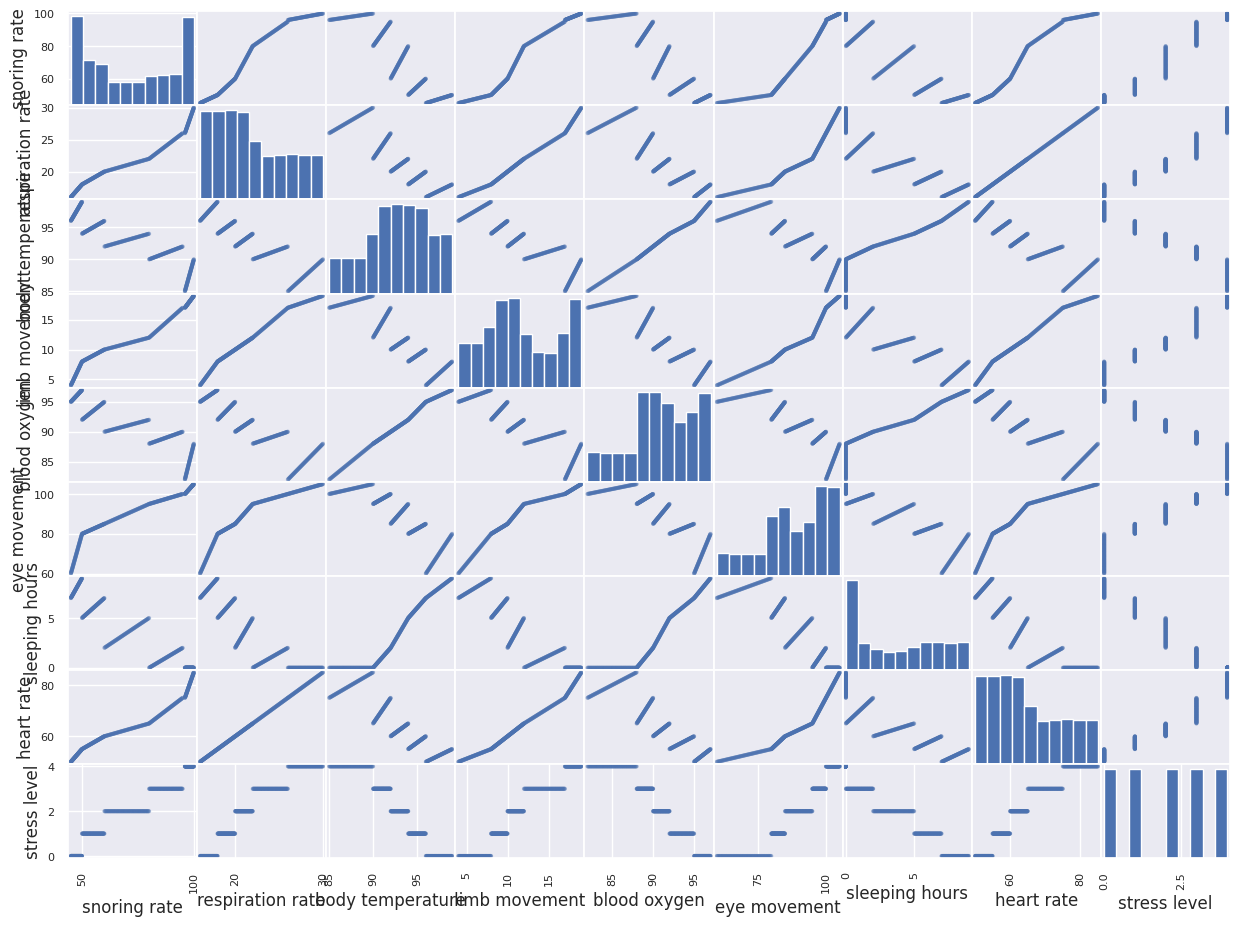

In [ ]:
from pandas.plotting import scatter_matrix

attributes = [i for i in df.columns]
scatter_matrix(df[attributes], figsize=(15, 11), alpha=0.3)

In [ ]:
def generate_metrics(y_true, y_pred):
  print("Accuracy Score : ", accuracy_score(y_true, y_pred))
  print("Confusion matrix")
  print(confusion_matrix(y_true, y_pred))
  print("Classification Report")
  print(classification_report(y_true, y_pred))


In [ ]:
def train_test_score(model, x_test, y_test, x_train, y_train):
  print("Training score ", model.score(x_train, y_train))
  print("Testing score ", model.score(x_test, y_test))

#**KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors = 5, algorithm = "kd_tree")
knn_model.fit(x_train, y_train)

KNeighborsClassifier(algorithm='kd_tree')

In [ ]:
print(x_test.shape)
print(y_test.shape)


(189, 8)
(189,)


In [ ]:
y_pred_knn = knn_model.predict(x_test)

print(y_pred_knn)

[0 1 0 2 1 1 2 4 1 3 3 3 4 2 3 3 0 2 1 2 0 1 3 4 4 4 2 3 4 1 2 4 3 0 4 3 0
 4 4 1 3 3 3 3 0 3 3 0 2 4 3 1 4 0 1 3 1 1 4 2 2 3 2 4 0 2 4 3 4 3 1 3 1 0
 4 2 3 4 1 1 4 2 1 3 4 4 1 4 4 1 3 0 3 4 1 0 2 2 0 0 2 1 2 0 1 3 4 2 3 4 1
 4 2 4 2 1 3 0 3 4 0 3 0 0 2 2 4 4 1 0 1 4 2 4 4 3 0 2 2 2 3 2 4 3 3 2 3 3
 1 4 0 2 1 2 3 0 2 3 1 3 2 4 1 1 4 3 2 1 1 0 2 2 0 2 0 0 4 1 0 4 3 0 3 1 0
 4 1 0 0]


In [ ]:
train_test_score(knn_model, x_test, y_test, x_train, y_train)

Training score  1.0
Testing score  1.0


In [ ]:
generate_metrics(y_test, y_pred_knn)

Accuracy Score :  1.0
Confusion matrix
[[33  0  0  0  0]
 [ 0 36  0  0  0]
 [ 0  0 37  0  0]
 [ 0  0  0 42  0]
 [ 0  0  0  0 41]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00        37
           3       1.00      1.00      1.00        42
           4       1.00      1.00      1.00        41

    accuracy                           1.00       189
   macro avg       1.00      1.00      1.00       189
weighted avg       1.00      1.00      1.00       189



# **Random Forest**

In [ ]:
ranForest= RandomForestClassifier()
ranForest.fit(x_train, y_train)
y_pred = ranForest.predict(x_test)
print(y_pred)
generate_metrics(y_test, y_pred)

from joblib import dump
filename = 'randomForest.joblib'
dump(ranForest,filename)

[0 1 0 2 1 1 2 4 1 3 3 3 4 2 3 3 0 2 1 2 0 1 3 4 4 4 2 3 4 1 2 4 3 0 4 3 0
 4 4 1 3 3 2 3 0 3 3 0 2 4 3 1 4 0 1 3 1 1 4 2 2 3 1 4 0 2 4 3 4 3 1 3 1 0
 4 2 3 4 1 1 4 2 1 3 4 4 1 4 4 1 3 0 3 4 1 0 2 2 0 0 2 1 2 0 1 3 4 2 3 4 1
 4 2 4 2 1 3 0 3 4 0 3 0 0 2 2 4 4 1 0 1 4 2 4 4 3 0 2 2 2 3 2 4 3 3 2 3 3
 1 4 0 2 1 2 3 0 2 3 1 3 2 4 1 1 4 3 2 1 1 0 2 2 0 2 0 0 4 1 0 4 3 0 3 1 0
 4 1 0 0]
Accuracy Score :  0.9894179894179894
Confusion matrix
[[33  0  0  0  0]
 [ 0 36  0  0  0]
 [ 0  1 36  0  0]
 [ 0  0  1 41  0]
 [ 0  0  0  0 41]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.99        36
           2       0.97      0.97      0.97        37
           3       1.00      0.98      0.99        42
           4       1.00      1.00      1.00        41

    accuracy                           0.99       189
   macro avg       0.99      0.99      0.99       189
weighted avg  

['randomForest.joblib']

# **Decision Tree**

In [ ]:
dt_model = tree.DecisionTreeClassifier()
dt_model.fit(x_train, y_train)



DecisionTreeClassifier()

In [ ]:
y_pred_dt = dt_model.predict(x_test)
xx_test = [[12, 30, 40, 60, 12, 4, 12, 34]]
print(y_pred_dt)
print(dt_model.predict(xx_test)[0])

[0 1 0 2 1 1 2 4 1 3 3 3 4 2 3 3 0 2 1 2 0 1 3 4 4 4 2 3 4 1 2 4 3 0 4 3 0
 4 4 1 3 3 2 3 0 3 3 0 2 4 3 1 4 0 1 3 1 1 4 2 2 3 1 4 0 2 4 3 4 3 1 3 1 0
 4 2 3 4 1 1 4 2 1 3 4 4 1 4 4 1 3 0 3 4 1 0 2 2 0 0 2 1 2 0 1 3 4 2 3 4 1
 4 2 4 2 1 3 0 3 4 0 3 0 0 1 2 4 4 1 0 1 4 2 4 4 3 0 2 2 2 3 2 4 3 3 2 3 3
 1 4 0 2 1 2 3 0 2 3 1 3 2 4 1 1 4 3 2 1 1 0 2 2 0 2 0 0 4 1 0 4 3 0 3 1 0
 4 1 1 0]
1


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
train_test_score(dt_model, x_test, y_test, x_train, y_train)


Training score  1.0
Testing score  0.9788359788359788


In [ ]:
generate_metrics(y_test, y_pred_dt)

Accuracy Score :  0.9788359788359788
Confusion matrix
[[32  1  0  0  0]
 [ 0 36  0  0  0]
 [ 0  2 35  0  0]
 [ 0  0  1 41  0]
 [ 0  0  0  0 41]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.92      1.00      0.96        36
           2       0.97      0.95      0.96        37
           3       1.00      0.98      0.99        42
           4       1.00      1.00      1.00        41

    accuracy                           0.98       189
   macro avg       0.98      0.98      0.98       189
weighted avg       0.98      0.98      0.98       189



[Text(0.5, 0.9, 'body temperature <= 96.024\ngini = 0.8\nsamples = 441\nvalue = [93, 90, 89, 84, 85]'),
 Text(0.3333333333333333, 0.7, 'eye movement <= 85.08\ngini = 0.75\nsamples = 348\nvalue = [0, 90, 89, 84, 85]'),
 Text(0.16666666666666666, 0.5, 'gini = 0.0\nsamples = 90\nvalue = [0, 90, 0, 0, 0]'),
 Text(0.5, 0.5, 'snoring rate <= 80.06\ngini = 0.666\nsamples = 258\nvalue = [0, 0, 89, 84, 85]'),
 Text(0.3333333333333333, 0.3, 'gini = 0.0\nsamples = 89\nvalue = [0, 0, 89, 0, 0]'),
 Text(0.6666666666666666, 0.3, 'sleep hours <= 0.008\ngini = 0.5\nsamples = 169\nvalue = [0, 0, 0, 84, 85]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 85\nvalue = [0, 0, 0, 0, 85]'),
 Text(0.8333333333333334, 0.1, 'gini = 0.0\nsamples = 84\nvalue = [0, 0, 0, 84, 0]'),
 Text(0.6666666666666666, 0.7, 'gini = 0.0\nsamples = 93\nvalue = [93, 0, 0, 0, 0]')]

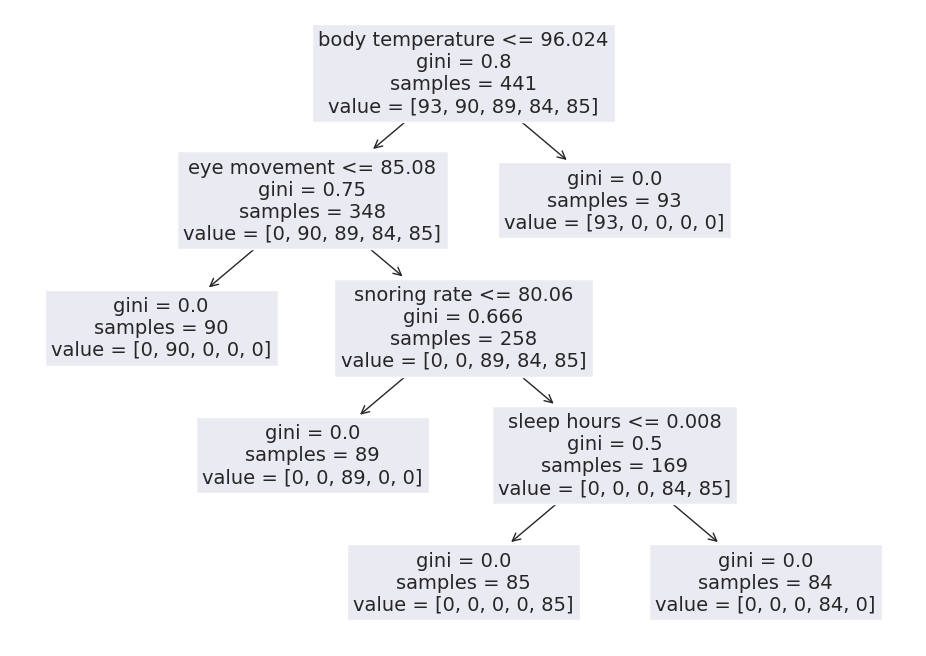

In [ ]:
tree.plot_tree(dt_model,feature_names=['snoring rate','respiration rate','body temperature','limb movement','body ohygen','eye movement','sleep hours','heart rate'])


In [ ]:
from joblib import dump
filename = 'model_knn.joblib'
dump(knn_model,filename)

['model_knn.joblib']

# **SVM**

In [ ]:
from sklearn.svm import SVC

In [ ]:
svc_model = SVC(C= .1, kernel='rbf', gamma= 1)
svc_model.fit(x_train, y_train)

SVC(C=0.1, gamma=1)

In [ ]:
w

[0 1 0 2 1 1 2 4 1 3 3 3 4 2 3 3 0 2 1 2 0 1 3 4 4 4 2 3 4 1 2 4 3 0 4 3 0
 4 4 1 3 3 3 3 0 3 3 0 2 4 3 1 4 0 1 3 1 1 4 2 2 3 2 4 0 2 4 3 4 3 1 3 1 0
 4 2 3 4 1 1 4 2 1 3 4 4 1 4 4 1 3 0 3 4 1 0 2 2 0 0 2 1 2 0 1 3 4 2 3 4 1
 4 2 4 2 1 3 0 3 4 0 3 0 0 2 2 4 4 1 0 1 4 2 4 4 3 0 2 2 2 3 2 4 3 3 2 3 3
 1 4 0 2 1 2 3 0 2 3 1 3 2 4 1 1 4 3 2 1 1 0 2 2 0 2 0 0 4 1 0 4 3 0 3 1 0
 4 1 0 0]


In [ ]:
train_test_score(svc_model, x_test, y_test, x_train, y_train)

Training score  1.0
Testing score  1.0


In [ ]:
generate_metrics(y_test, y_pred_svc)

Accuracy Score :  1.0
Confusion matrix
[[33  0  0  0  0]
 [ 0 36  0  0  0]
 [ 0  0 37  0  0]
 [ 0  0  0 42  0]
 [ 0  0  0  0 41]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00        37
           3       1.00      1.00      1.00        42
           4       1.00      1.00      1.00        41

    accuracy                           1.00       189
   macro avg       1.00      1.00      1.00       189
weighted avg       1.00      1.00      1.00       189



#**Comparision Table**

In [ ]:
ac_knn = accuracy_score(y_test, y_pred_knn)
ac_dt =  accuracy_score(y_test, y_pred_dt)
ac_svm = accuracy_score(y_test, y_pred_svc)
models = {'K-Nearest Neighbors': ac_knn,
          'Decision Tree': ac_dt,
          'SVM' : ac_svm
          }



In [ ]:

df1 = pd.DataFrame(list(models.items()), columns=['Model', 'Accuracy'])
print(df1)

                 Model  Accuracy
0  K-Nearest Neighbors  1.000000
1        Decision Tree  0.978836
2                  SVM  1.000000


([<matplotlib.patches.Wedge at 0x7bd32e0a8ca0>,
 [Text(0.5428972133803811, 0.9566935850646314, 'KNN'),
  Text(-1.0999999999999954, 1.0298943285007232e-07, 'Decision Tree'),
  Text(0.5428970342361357, -0.9566936867240258, 'SVM')])

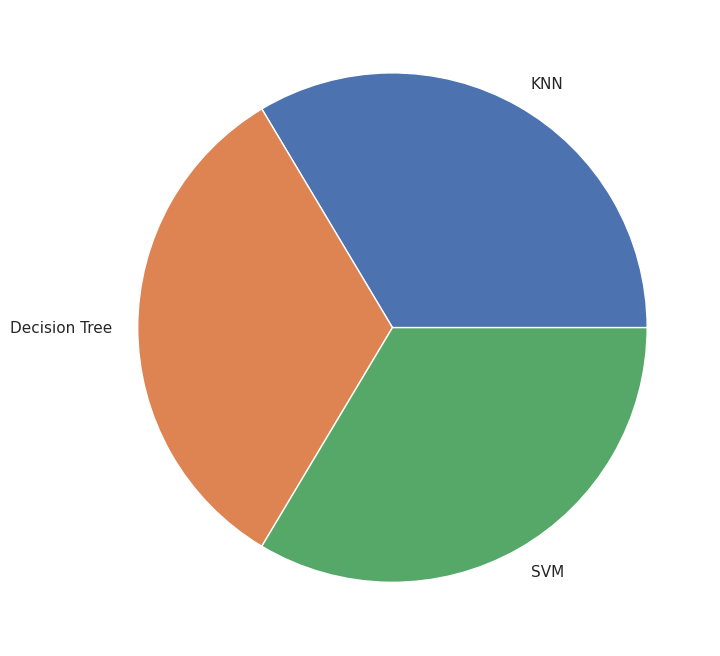

In [ ]:
labels = ["KNN", "Decision Tree", "SVM"]
scores = [ac_knn, ac_dt, ac_svm]
plt.pie(scores, labels = labels)